In [1]:
import sys
print(sys.executable)

c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import sklearn
import pyarrow
import fastapi

print("Todo OK")


Todo OK


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_EXTERNAL.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)

Project root: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction
Raw data folder: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\data\raw


In [4]:
import urllib.request
from pathlib import Path

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-05.parquet"
output_path = DATA_RAW / "yellow_tripdata_2022-05.parquet"

if output_path.exists():
    print(f"Dataset already exists: {output_path}")
else:
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, output_path)
    print(f"Downloaded to: {output_path}")

print("File size MB:", round(output_path.stat().st_size / (1024 * 1024), 2))

Dataset already exists: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\data\raw\yellow_tripdata_2022-05.parquet
File size MB: 52.99


In [5]:
output_path.exists(), round(output_path.stat().st_size / (1024 * 1024), 2)


(True, 52.99)

In [6]:
import pandas as pd

df = pd.read_parquet(output_path, engine="pyarrow")

print(df.shape)
df.head()

(3588295, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


In [7]:
df.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3588295 entries, 0 to 3588294
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [9]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

store_and_fwd_flag       129524
RatecodeID               129524
passenger_count          129524
airport_fee              129524
congestion_surcharge     129524
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
DOLocationID                  0
PULocationID                  0
trip_distance                 0
fare_amount                   0
payment_type                  0
extra                         0
mta_tax                       0
tolls_amount                  0
tip_amount                    0
total_amount                  0
improvement_surcharge         0
dtype: int64

In [10]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent

store_and_fwd_flag       3.609625
RatecodeID               3.609625
passenger_count          3.609625
airport_fee              3.609625
congestion_surcharge     3.609625
VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
DOLocationID             0.000000
PULocationID             0.000000
trip_distance            0.000000
fare_amount              0.000000
payment_type             0.000000
extra                    0.000000
mta_tax                  0.000000
tolls_amount             0.000000
tip_amount               0.000000
total_amount             0.000000
improvement_surcharge    0.000000
dtype: float64

In [11]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_minutes"]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes
0,2022-05-01 00:00:36,2022-05-01 00:19:18,18.700000
1,2022-05-01 00:27:44,2022-05-01 00:41:33,13.816667
2,2022-05-01 00:59:00,2022-05-01 01:14:22,15.366667
3,2022-05-01 00:48:18,2022-05-01 01:28:02,39.733333
4,2022-05-01 00:28:26,2022-05-01 00:37:49,9.383333


In [12]:
main_columns = [
    "fare_amount",
    "trip_duration_minutes",
    "trip_distance",
    "passenger_count",
    "RatecodeID",
    "PULocationID",
    "DOLocationID"
]

df[main_columns].describe()

,fare_amount,trip_duration_minutes,trip_distance,passenger_count,RatecodeID,PULocationID,DOLocationID
count,3.588295e+06,3.588295e+06,3.588295e+06,3.458771e+06,3.458771e+06,3.588295e+06,3.588295e+06
mean,1.516813e+01,1.821760e+01,6.856861e+00,1.393923e+00,1.365674e+00,1.645738e+02,1.625517e+02
std,1.489484e+01,5.156663e+01,6.908488e+02,9.555489e-01,5.239789e+00,6.562813e+01,7.027926e+01
min,-1.311500e+03,-1.408333e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,7.000000e+00,7.666667e+00,1.150000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.130000e+02
50%,1.050000e+01,1.270000e+01,1.960000e+00,1.000000e+00,1.000000e+00,1.620000e+02,1.620000e+02
75%,1.700000e+01,2.061667e+01,3.730000e+00,1.000000e+00,1.000000e+00,2.340000e+02,2.340000e+02
max,6.966500e+03,6.823550e+03,3.571927e+05,9.000000e+00,9.900000e+01,2.650000e+02,2.650000e+02


In [13]:
numeric_cols = [
    "fare_amount",
    "trip_duration_minutes",
    "trip_distance",
    "passenger_count",
    "RatecodeID"
]

percentiles = df[numeric_cols].quantile([
    0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999
])

percentiles

,fare_amount,trip_duration_minutes,trip_distance,passenger_count,RatecodeID
0.001,-22.0,0.033333,0.00,0.0,1.0
0.010,2.5,0.383333,0.00,0.0,1.0
0.050,4.5,3.350000,0.50,1.0,1.0
0.250,7.0,7.666667,1.15,1.0,1.0
0.500,10.5,12.700000,1.96,1.0,1.0
0.750,17.0,20.616667,3.73,1.0,1.0
0.950,52.0,43.950000,16.00,3.0,2.0
0.990,63.0,71.450000,20.30,6.0,5.0
0.999,119.0,1397.528433,29.70,6.0,99.0


In [14]:
df["RatecodeID"].value_counts(dropna=False).sort_index()

RatecodeID
1.0     3256985
2.0      147239
3.0       11636
4.0        4626
5.0       28382
6.0          39
99.0       9864
NaN      129524
Name: count, dtype: int64

In [15]:
valid_ratecodes = [1, 2, 3, 4, 5, 6]

df_clean = df[
    (df["fare_amount"] > 0) &
    (df["fare_amount"] <= 200) &
    (df["trip_duration_minutes"] >= 1) &
    (df["trip_duration_minutes"] <= 180) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 100) &
    (df["passenger_count"] >= 1) &
    (df["passenger_count"] <= 6) &
    (df["RatecodeID"].isin(valid_ratecodes))
].copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])
print("Percentage removed:", round((df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100, 2), "%")

Original shape: (3588295, 20)
Clean shape: (3297793, 20)
Rows removed: 290502
Percentage removed: 8.1 %


In [16]:
df_clean[[
    "fare_amount",
    "trip_duration_minutes",
    "trip_distance",
    "passenger_count",
    "RatecodeID"
]].describe()

,fare_amount,trip_duration_minutes,trip_distance,passenger_count,RatecodeID
count,3.297793e+06,3.297793e+06,3.297793e+06,3.297793e+06,3.297793e+06
mean,1.477973e+01,1.637587e+01,3.642096e+00,1.425730e+00,1.063621e+00
std,1.296058e+01,1.325909e+01,4.538348e+00,9.452087e-01,3.296921e-01
min,1.000000e-02,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00
25%,7.000000e+00,7.766667e+00,1.180000e+00,1.000000e+00,1.000000e+00
50%,1.050000e+01,1.265000e+01,1.950000e+00,1.000000e+00,1.000000e+00
75%,1.650000e+01,2.036667e+01,3.670000e+00,1.000000e+00,1.000000e+00
max,2.000000e+02,1.799000e+02,8.720000e+01,6.000000e+00,6.000000e+00


In [17]:
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["pickup_day"] = df_clean["tpep_pickup_datetime"].dt.day
df_clean["pickup_weekday"] = df_clean["tpep_pickup_datetime"].dt.weekday
df_clean["pickup_month"] = df_clean["tpep_pickup_datetime"].dt.month
df_clean["is_weekend"] = df_clean["pickup_weekday"].isin([5, 6]).astype(int)

df_clean[
    [
        "tpep_pickup_datetime",
        "pickup_hour",
        "pickup_day",
        "pickup_weekday",
        "pickup_month",
        "is_weekend"
    ]
].head()

,tpep_pickup_datetime,pickup_hour,pickup_day,pickup_weekday,pickup_month,is_weekend
0,2022-05-01 00:00:36,0,1,6,5,1
1,2022-05-01 00:27:44,0,1,6,5,1
2,2022-05-01 00:59:00,0,1,6,5,1
4,2022-05-01 00:28:26,0,1,6,5,1
5,2022-04-30 23:53:47,23,30,5,4,1


In [18]:
df_clean[
    [
        "pickup_hour",
        "pickup_day",
        "pickup_weekday",
        "pickup_month",
        "is_weekend"
    ]
].describe()

,pickup_hour,pickup_day,pickup_weekday,pickup_month,is_weekend
count,3.297793e+06,3.297793e+06,3.297793e+06,3.297793e+06,3.297793e+06
mean,1.422409e+01,1.576474e+01,2.907462e+00,4.999977e+00,2.682567e-01
std,5.745158e+00,8.700026e+00,1.997767e+00,8.741524e-03,4.430520e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.100000e+01,8.000000e+00,1.000000e+00,5.000000e+00,0.000000e+00
50%,1.500000e+01,1.600000e+01,3.000000e+00,5.000000e+00,0.000000e+00
75%,1.900000e+01,2.300000e+01,5.000000e+00,5.000000e+00,1.000000e+00
max,2.300000e+01,3.100000e+01,6.000000e+00,1.200000e+01,1.000000e+00


In [19]:
df_clean["pickup_month"].value_counts().sort_index()

pickup_month
1           2
4         102
5     3297667
6          20
12          2
Name: count, dtype: int64

In [20]:
df_clean["tpep_pickup_datetime"].min(), df_clean["tpep_pickup_datetime"].max()

(Timestamp('2003-01-01 00:06:06'), Timestamp('2022-06-01 23:55:30'))

In [21]:
df_clean = df_clean[
    (df_clean["tpep_pickup_datetime"] >= "2022-05-01") &
    (df_clean["tpep_pickup_datetime"] < "2022-06-01")
].copy()

print("Clean May 2022 shape:", df_clean.shape)
df_clean["pickup_month"].value_counts().sort_index()


Clean May 2022 shape: (3297667, 25)


pickup_month
5    3297667
Name: count, dtype: int64

In [22]:
df_clean["tpep_pickup_datetime"].min(), df_clean["tpep_pickup_datetime"].max()

(Timestamp('2022-05-01 00:00:01'), Timestamp('2022-05-31 23:59:59'))

In [23]:
trips_by_hour = df_clean["pickup_hour"].value_counts().sort_index()

trips_by_hour

pickup_hour
0      92459
1      59408
2      38091
3      24054
4      15658
5      20210
6      51629
7      94838
8     122138
9     140433
10    157714
11    174864
12    186893
13    188243
14    200829
15    204801
16    203402
17    219460
18    234348
19    214985
20    183183
21    177912
22    161208
23    130907
Name: count, dtype: int64

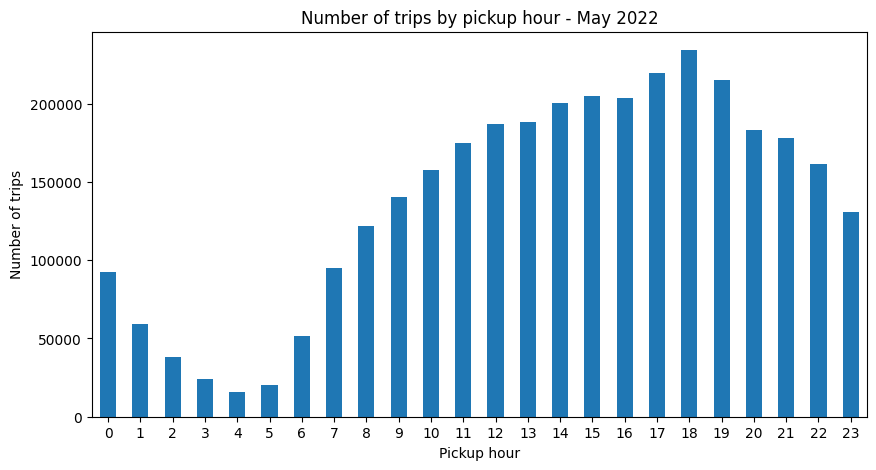

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
trips_by_hour.plot(kind="bar")
plt.title("Number of trips by pickup hour - May 2022")
plt.xlabel("Pickup hour")
plt.ylabel("Number of trips")
plt.xticks(rotation=0)
plt.show()


In [25]:
trips_by_weekday = df_clean["pickup_weekday"].value_counts().sort_index()

trips_by_weekday

pickup_weekday
0    469924
1    554839
2    462856
3    475634
4    449861
5    426566
6    457987
Name: count, dtype: int64

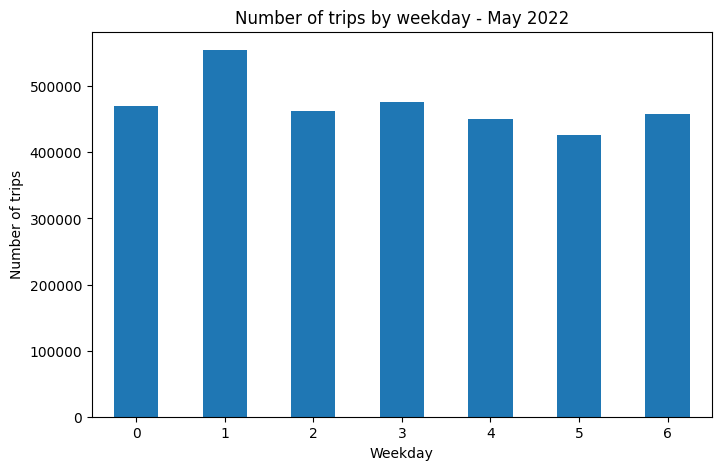

In [26]:
plt.figure(figsize=(8, 5))
trips_by_weekday.plot(kind="bar")
plt.title("Number of trips by weekday - May 2022")
plt.xlabel("Weekday")
plt.ylabel("Number of trips")
plt.xticks(rotation=0)
plt.show()

In [27]:
hourly_patterns = df_clean.groupby("pickup_hour").agg(
    avg_fare=("fare_amount", "mean"),
    avg_duration=("trip_duration_minutes", "mean"),
    avg_distance=("trip_distance", "mean"),
    total_trips=("fare_amount", "count")
)

hourly_patterns

,avg_fare,avg_duration,avg_distance,total_trips
pickup_hour,,,,
0,15.429418,14.082835,4.313210,92459
1,14.279708,12.903271,3.950192,59408
2,13.148355,12.110530,3.559026,38091
3,14.181380,12.432826,3.935231,24054
4,19.105881,14.359017,5.678400,15658
5,21.647879,15.171317,6.704851,20210
6,17.057959,14.780875,5.012733,51629
7,15.125083,15.663680,4.032520,94838
8,14.636978,16.246206,3.619448,122138


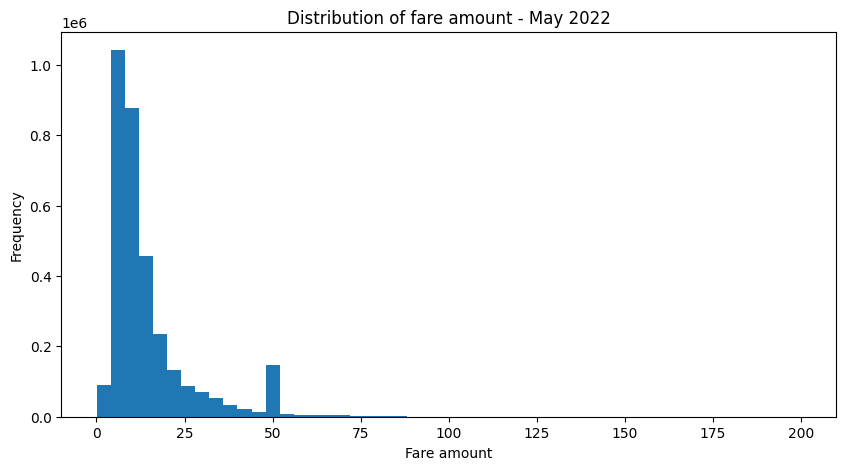

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["fare_amount"], bins=50)
plt.title("Distribution of fare amount - May 2022")
plt.xlabel("Fare amount")
plt.ylabel("Frequency")
plt.show()

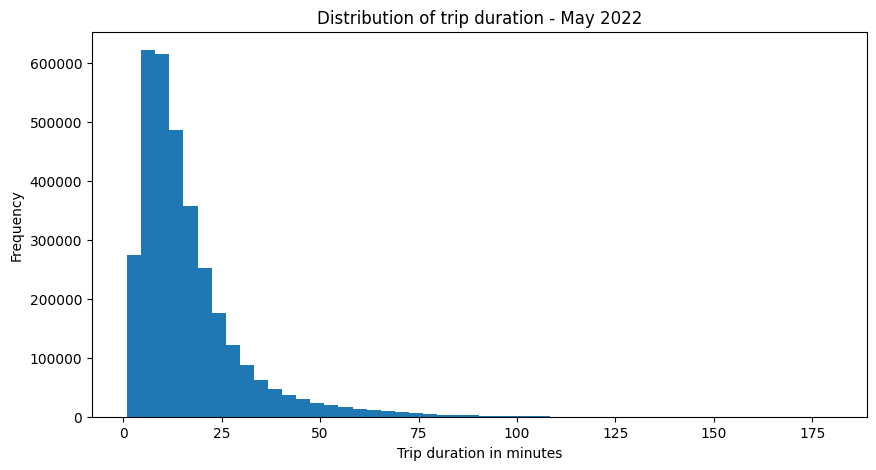

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["trip_duration_minutes"], bins=50)
plt.title("Distribution of trip duration - May 2022")
plt.xlabel("Trip duration in minutes")
plt.ylabel("Frequency")
plt.show()

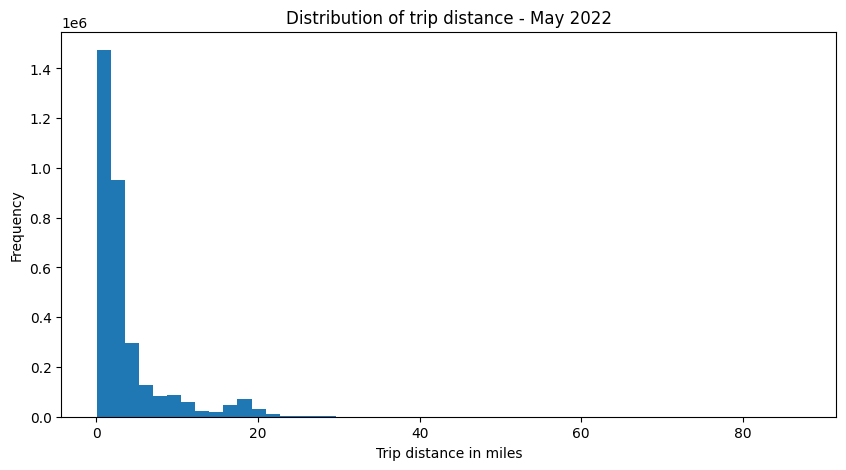

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["trip_distance"], bins=50)
plt.title("Distribution of trip distance - May 2022")
plt.xlabel("Trip distance in miles")
plt.ylabel("Frequency")
plt.show()

In [31]:
df_clean[["fare_amount", "trip_duration_minutes", "trip_distance"]].describe()

,fare_amount,trip_duration_minutes,trip_distance
count,3.297667e+06,3.297667e+06,3.297667e+06
mean,1.477975e+01,1.637591e+01,3.642092e+00
std,1.296066e+01,1.325903e+01,4.538365e+00
min,1.000000e-02,1.000000e+00,1.000000e-02
25%,7.000000e+00,7.766667e+00,1.180000e+00
50%,1.050000e+01,1.265000e+01,1.950000e+00
75%,1.650000e+01,2.036667e+01,3.670000e+00
max,2.000000e+02,1.799000e+02,8.720000e+01


In [32]:
df_clean[["fare_amount", "trip_duration_minutes", "trip_distance"]].corr()

,fare_amount,trip_duration_minutes,trip_distance
fare_amount,1.000000,0.862815,0.950605
trip_duration_minutes,0.862815,1.000000,0.817276
trip_distance,0.950605,0.817276,1.000000


The correlation analysis shows that trip distance has a very strong positive relationship with fare amount (0.95) and a strong relationship with trip duration (0.82). This confirms that trip distance is one of the most relevant predictors for both targets. Fare amount and trip duration are also strongly correlated, but trip duration should not be used as a feature for fare prediction because it would not be known at the beginning of the ride.

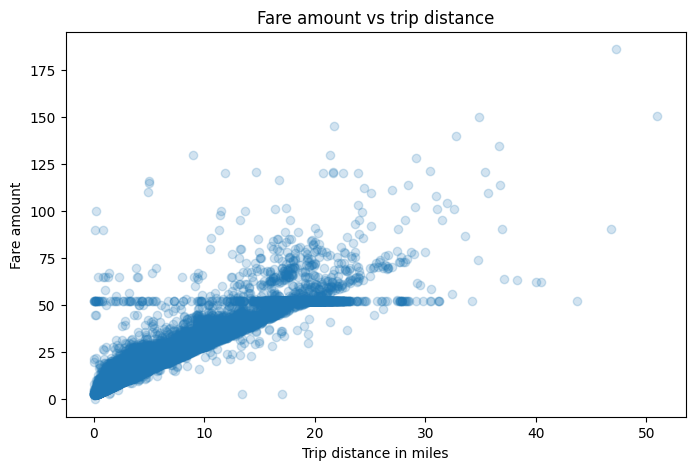

In [33]:
sample_df = df_clean.sample(n=50000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["trip_distance"], sample_df["fare_amount"], alpha=0.2)
plt.title("Fare amount vs trip distance")
plt.xlabel("Trip distance in miles")
plt.ylabel("Fare amount")
plt.show()

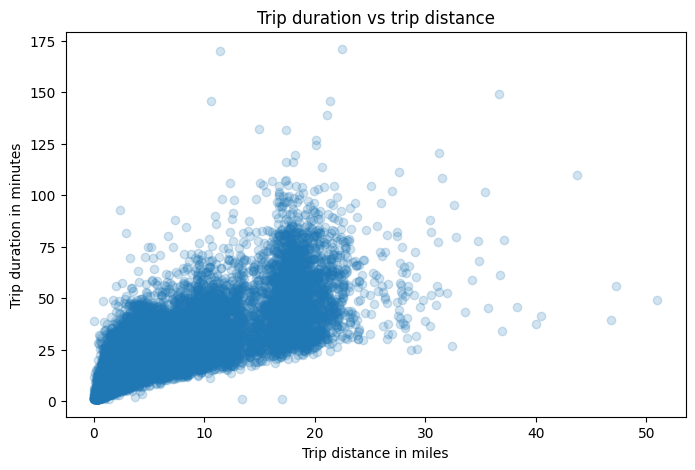

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df["trip_distance"], sample_df["trip_duration_minutes"], alpha=0.2)
plt.title("Trip duration vs trip distance")
plt.xlabel("Trip distance in miles")
plt.ylabel("Trip duration in minutes")
plt.show()

The scatter plot between fare amount and trip distance shows a strong positive relationship: longer trips generally have higher fares. This confirms that trip distance is a key predictor for fare amount. Some horizontal patterns can also be observed, which may be related to fixed fares or special rate codes.

The relationship between trip duration and trip distance is also positive, although more dispersed than fare vs distance. This suggests that distance is important for duration prediction, but temporal and location-based features are also likely to contribute because travel time depends on traffic conditions and pickup/dropoff areas.

In [35]:
feature_columns = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_day",
    "pickup_weekday",
    "is_weekend"
]

target_fare = "fare_amount"
target_duration = "trip_duration_minutes"

X = df_clean[feature_columns].copy()
y_fare = df_clean[target_fare].copy()
y_duration = df_clean[target_duration].copy()

print("X shape:", X.shape)
print("y_fare shape:", y_fare.shape)
print("y_duration shape:", y_duration.shape)

X.head()

X shape: (3297667, 10)
y_fare shape: (3297667,)
y_duration shape: (3297667,)


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,pickup_hour,pickup_day,pickup_weekday,is_weekend
0,1,1.0,4.10,1.0,246,151,0,1,6,1
1,1,1.0,2.30,1.0,238,74,0,1,6,1
2,1,1.0,4.20,1.0,163,260,0,1,6,1
4,1,1.0,1.60,1.0,238,75,0,1,6,1
6,2,1.0,3.35,1.0,164,112,0,1,6,1


In [36]:
split_date = "2022-05-25"

train_mask = df_clean["tpep_pickup_datetime"] < split_date
test_mask = df_clean["tpep_pickup_datetime"] >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_fare_train = y_fare.loc[train_mask]
y_fare_test = y_fare.loc[test_mask]

y_duration_train = y_duration.loc[train_mask]
y_duration_test = y_duration.loc[test_mask]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_fare_train:", y_fare_train.shape)
print("y_fare_test:", y_fare_test.shape)
print("y_duration_train:", y_duration_train.shape)
print("y_duration_test:", y_duration_test.shape)

X_train: (2613824, 10)
X_test: (683843, 10)
y_fare_train: (2613824,)
y_fare_test: (683843,)
y_duration_train: (2613824,)
y_duration_test: (683843,)


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

fare_lr = LinearRegression()

start_time = time.time()
fare_lr.fit(X_train, y_fare_train)
training_time = time.time() - start_time

start_time = time.time()
y_fare_pred = fare_lr.predict(X_test)
inference_time = time.time() - start_time

fare_mae = mean_absolute_error(y_fare_test, y_fare_pred)
fare_rmse = np.sqrt(mean_squared_error(y_fare_test, y_fare_pred))
fare_r2 = r2_score(y_fare_test, y_fare_pred)

print("Fare Linear Regression Results")
print("MAE:", round(fare_mae, 4))
print("RMSE:", round(fare_rmse, 4))
print("R2:", round(fare_r2, 4))
print("Training time:", round(training_time, 2), "seconds")
print("Inference time:", round(inference_time, 2), "seconds")

Fare Linear Regression Results
MAE: 2.2692
RMSE: 3.6723
R2: 0.9227
Training time: 1.7 seconds
Inference time: 0.09 seconds


In [38]:
duration_lr = LinearRegression()

start_time = time.time()
duration_lr.fit(X_train, y_duration_train)
training_time = time.time() - start_time

start_time = time.time()
y_duration_pred = duration_lr.predict(X_test)
inference_time = time.time() - start_time

duration_mae = mean_absolute_error(y_duration_test, y_duration_pred)
duration_rmse = np.sqrt(mean_squared_error(y_duration_test, y_duration_pred))
duration_r2 = r2_score(y_duration_test, y_duration_pred)

print("Duration Linear Regression Results")
print("MAE:", round(duration_mae, 4))
print("RMSE:", round(duration_rmse, 4))
print("R2:", round(duration_r2, 4))
print("Training time:", round(training_time, 2), "seconds")
print("Inference time:", round(inference_time, 2), "seconds")

Duration Linear Regression Results
MAE: 5.6115
RMSE: 7.7773
R2: 0.6469
Training time: 1.49 seconds
Inference time: 0.08 seconds


In [39]:
baseline_results = pd.DataFrame([
    {
        "target": "fare_amount",
        "model": "Linear Regression",
        "MAE": fare_mae,
        "RMSE": fare_rmse,
        "R2": fare_r2
    },
    {
        "target": "trip_duration_minutes",
        "model": "Linear Regression",
        "MAE": duration_mae,
        "RMSE": duration_rmse,
        "R2": duration_r2
    }
])

baseline_results

,target,model,MAE,RMSE,R2
0,fare_amount,Linear Regression,2.269191,3.672279,0.922654
1,trip_duration_minutes,Linear Regression,5.611470,7.777312,0.646946


The baseline Linear Regression model achieved strong performance for fare prediction, with an MAE of approximately 2.27 USD and an R2 score of 0.92. This suggests that the selected features, especially trip distance, explain most of the variability in taxi fares.

For trip duration prediction, the baseline model achieved an MAE of approximately 5.61 minutes and an R2 score of 0.65. This lower performance indicates that duration is harder to predict using only basic pickup time, distance, passenger count, rate code, and location ID features. Travel duration is likely affected by additional external factors such as traffic congestion, road conditions, weather, and specific routes.

In [40]:
from sklearn.tree import DecisionTreeRegressor

fare_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=50,
    random_state=42
)

start_time = time.time()
fare_tree.fit(X_train, y_fare_train)
training_time = time.time() - start_time

start_time = time.time()
y_fare_pred_tree = fare_tree.predict(X_test)
inference_time = time.time() - start_time

fare_tree_mae = mean_absolute_error(y_fare_test, y_fare_pred_tree)
fare_tree_rmse = np.sqrt(mean_squared_error(y_fare_test, y_fare_pred_tree))
fare_tree_r2 = r2_score(y_fare_test, y_fare_pred_tree)

print("Fare Decision Tree Results")
print("MAE:", round(fare_tree_mae, 4))
print("RMSE:", round(fare_tree_rmse, 4))
print("R2:", round(fare_tree_r2, 4))
print("Training time:", round(training_time, 2), "seconds")
print("Inference time:", round(inference_time, 2), "seconds")

Fare Decision Tree Results
MAE: 1.4604
RMSE: 2.594
R2: 0.9614
Training time: 23.95 seconds
Inference time: 0.22 seconds


In [41]:
duration_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=50,
    random_state=42
)

start_time = time.time()
duration_tree.fit(X_train, y_duration_train)
training_time = time.time() - start_time

start_time = time.time()
y_duration_pred_tree = duration_tree.predict(X_test)
inference_time = time.time() - start_time

duration_tree_mae = mean_absolute_error(y_duration_test, y_duration_pred_tree)
duration_tree_rmse = np.sqrt(mean_squared_error(y_duration_test, y_duration_pred_tree))
duration_tree_r2 = r2_score(y_duration_test, y_duration_pred_tree)

print("Duration Decision Tree Results")
print("MAE:", round(duration_tree_mae, 4))
print("RMSE:", round(duration_tree_rmse, 4))
print("R2:", round(duration_tree_r2, 4))
print("Training time:", round(training_time, 2), "seconds")
print("Inference time:", round(inference_time, 2), "seconds")

Duration Decision Tree Results
MAE: 4.0044
RMSE: 6.2425
R2: 0.7725
Training time: 22.27 seconds
Inference time: 0.44 seconds


In [42]:
model_results = pd.DataFrame([
    {
        "target": "fare_amount",
        "model": "Linear Regression",
        "MAE": fare_mae,
        "RMSE": fare_rmse,
        "R2": fare_r2
    },
    {
        "target": "fare_amount",
        "model": "Decision Tree",
        "MAE": fare_tree_mae,
        "RMSE": fare_tree_rmse,
        "R2": fare_tree_r2
    },
    {
        "target": "trip_duration_minutes",
        "model": "Linear Regression",
        "MAE": duration_mae,
        "RMSE": duration_rmse,
        "R2": duration_r2
    },
    {
        "target": "trip_duration_minutes",
        "model": "Decision Tree",
        "MAE": duration_tree_mae,
        "RMSE": duration_tree_rmse,
        "R2": duration_tree_r2
    }
])

model_results

,target,model,MAE,RMSE,R2
0,fare_amount,Linear Regression,2.269191,3.672279,0.922654
1,fare_amount,Decision Tree,1.460445,2.594029,0.961406
2,trip_duration_minutes,Linear Regression,5.611470,7.777312,0.646946
3,trip_duration_minutes,Decision Tree,4.004422,6.242543,0.772540


In [43]:
model_results.sort_values(["target", "MAE"])


,target,model,MAE,RMSE,R2
1,fare_amount,Decision Tree,1.460445,2.594029,0.961406
0,fare_amount,Linear Regression,2.269191,3.672279,0.922654
3,trip_duration_minutes,Decision Tree,4.004422,6.242543,0.772540
2,trip_duration_minutes,Linear Regression,5.611470,7.777312,0.646946


The Decision Tree model improved performance for both prediction tasks compared with the Linear Regression baseline. For fare prediction, MAE decreased from approximately 2.27 USD to 1.46 USD, while R2 increased from 0.92 to 0.96. For duration prediction, MAE decreased from approximately 5.61 minutes to 4.00 minutes, while R2 increased from 0.65 to 0.77.

These results suggest that non-linear relationships between trip distance, pickup time, location IDs, passenger count, and rate code are relevant for both fare and duration prediction. Duration remains harder to predict than fare, likely because travel time depends on additional external factors such as traffic congestion, road conditions, and weather.

In [44]:
fare_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": fare_tree.feature_importances_
}).sort_values("importance", ascending=False)

fare_importance

,feature,importance
2,trip_distance,0.936996
3,RatecodeID,0.051370
6,pickup_hour,0.005783
5,DOLocationID,0.002880
8,pickup_weekday,0.001106
4,PULocationID,0.000851
7,pickup_day,0.000547
9,is_weekend,0.000294
0,VendorID,0.000160
1,passenger_count,0.000012


For fare prediction, trip_distance is by far the most important feature, representing approximately 93.7% of the total feature importance in the Decision Tree model. This is expected because taxi fare is highly dependent on the distance traveled. RatecodeID is the second most relevant feature, suggesting that different fare types also affect the final fare amount. Temporal and location-based features have lower importance for this target.

In [45]:
duration_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": duration_tree.feature_importances_
}).sort_values("importance", ascending=False)

duration_importance

,feature,importance
2,trip_distance,0.853002
6,pickup_hour,0.095822
8,pickup_weekday,0.013889
7,pickup_day,0.010014
9,is_weekend,0.009590
4,PULocationID,0.008999
5,DOLocationID,0.006177
3,RatecodeID,0.002489
0,VendorID,0.000010
1,passenger_count,0.000008


For trip duration prediction, trip_distance is also the most important feature, but pickup_hour has a much higher relevance than in fare prediction. This suggests that travel duration is more affected by temporal traffic patterns. Weekday, day of month, weekend indicator, and pickup/dropoff location IDs also contribute to the model, which is consistent with the idea that duration depends on distance, traffic conditions, and location-specific patterns.

In [46]:
processed_path = DATA_PROCESSED / "yellow_tripdata_2022-05_clean.parquet"

df_clean.to_parquet(processed_path, index=False)

print("Clean dataset saved to:", processed_path)
print("Shape:", df_clean.shape)

Clean dataset saved to: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\data\processed\yellow_tripdata_2022-05_clean.parquet
Shape: (3297667, 25)


In [47]:
df_check = pd.read_parquet(processed_path)
print(df_check.shape)
df_check.head()

(3297667, 25)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_minutes,pickup_hour,pickup_day,pickup_weekday,pickup_month,is_weekend
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.10,1.0,N,246,151,2,...,0.3,20.80,2.5,0.0,18.700000,0,1,6,5,1
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.30,1.0,N,238,74,2,...,0.3,14.80,2.5,0.0,13.816667,0,1,6,5,1
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.20,1.0,N,163,260,2,...,0.3,19.30,2.5,0.0,15.366667,0,1,6,5,1
3,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.60,1.0,N,238,75,1,...,0.3,13.55,2.5,0.0,9.383333,0,1,6,5,1
4,2,2022-05-01 00:07:11,2022-05-01 00:19:24,1.0,3.35,1.0,N,164,112,1,...,0.3,26.28,2.5,0.0,12.216667,0,1,6,5,1


In [48]:
import joblib

fare_model_path = PROJECT_ROOT / "models" / "fare_decision_tree_model.pkl"
duration_model_path = PROJECT_ROOT / "models" / "duration_decision_tree_model.pkl"

joblib.dump(fare_tree, fare_model_path)
joblib.dump(duration_tree, duration_model_path)

print("Fare model saved to:", fare_model_path)
print("Duration model saved to:", duration_model_path)

Fare model saved to: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\models\fare_decision_tree_model.pkl
Duration model saved to: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\models\duration_decision_tree_model.pkl


In [49]:
loaded_fare_model = joblib.load(fare_model_path)
loaded_duration_model = joblib.load(duration_model_path)

print("Models loaded successfully")

Models loaded successfully


In [50]:
sample_input = X_test.iloc[[0]]

fare_prediction = loaded_fare_model.predict(sample_input)
duration_prediction = loaded_duration_model.predict(sample_input)

print("Sample input:")
display(sample_input)

print("Predicted fare:", round(fare_prediction[0], 2))
print("Predicted duration minutes:", round(duration_prediction[0], 2))

print("Actual fare:", round(y_fare_test.iloc[0], 2))
print("Actual duration minutes:", round(y_duration_test.iloc[0], 2))


Sample input:


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,pickup_hour,pickup_day,pickup_weekday,is_weekend
2736158,2,5.0,2.0,1.0,229,79,0,25,2,0


Predicted fare: 8.99
Predicted duration minutes: 8.97
Actual fare: 7.5
Actual duration minutes: 5.18


In [51]:
import json

features_path = PROJECT_ROOT / "models" / "feature_columns.json"

with open(features_path, "w") as f:
    json.dump(feature_columns, f, indent=4)

print("Feature columns saved to:", features_path)
print(feature_columns)

Feature columns saved to: c:\Users\pc\Desktop\nyc-taxi-fare-duration-prediction\models\feature_columns.json
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_day', 'pickup_weekday', 'is_weekend']


In [52]:
with open(features_path, "r") as f:
    loaded_features = json.load(f)

loaded_features

['VendorID',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'pickup_hour',
 'pickup_day',
 'pickup_weekday',
 'is_weekend']

In [53]:
model_results = pd.DataFrame([
    {
        "target": "fare_amount",
        "model": "Linear Regression",
        "MAE": fare_mae,
        "RMSE": fare_rmse,
        "R2": fare_r2
    },
    {
        "target": "fare_amount",
        "model": "Decision Tree",
        "MAE": fare_tree_mae,
        "RMSE": fare_tree_rmse,
        "R2": fare_tree_r2
    },
    {
        "target": "trip_duration_minutes",
        "model": "Linear Regression",
        "MAE": duration_mae,
        "RMSE": duration_rmse,
        "R2": duration_r2
    },
    {
        "target": "trip_duration_minutes",
        "model": "Decision Tree",
        "MAE": duration_tree_mae,
        "RMSE": duration_tree_rmse,
        "R2": duration_tree_r2
    }
])

model_results

,target,model,MAE,RMSE,R2
0,fare_amount,Linear Regression,2.269191,3.672279,0.922654
1,fare_amount,Decision Tree,1.460445,2.594029,0.961406
2,trip_duration_minutes,Linear Regression,5.611470,7.777312,0.646946
3,trip_duration_minutes,Decision Tree,4.004422,6.242543,0.772540


In [54]:
model_results.sort_values(["target", "MAE"])

,target,model,MAE,RMSE,R2
1,fare_amount,Decision Tree,1.460445,2.594029,0.961406
0,fare_amount,Linear Regression,2.269191,3.672279,0.922654
3,trip_duration_minutes,Decision Tree,4.004422,6.242543,0.772540
2,trip_duration_minutes,Linear Regression,5.611470,7.777312,0.646946


## Initial Modeling Conclusions

Two regression targets were modeled: `fare_amount` and `trip_duration_minutes`.

The Linear Regression model was used as a baseline. It performed strongly for fare prediction, mainly because fare amount has a very strong relationship with trip distance. However, its performance was weaker for duration prediction, which is expected because trip duration depends on additional factors such as traffic, pickup time, day of week, and pickup/dropoff locations.

The Decision Tree Regressor improved performance for both targets. For fare prediction, the MAE decreased from approximately 2.27 USD to 1.46 USD, and the R2 score increased from 0.92 to 0.96. For duration prediction, the MAE decreased from approximately 5.61 minutes to 4.00 minutes, and the R2 score increased from 0.65 to 0.77.

Feature importance analysis showed that `trip_distance` is the most important feature for both targets. `RatecodeID` is especially relevant for fare prediction, while `pickup_hour` is more important for duration prediction. This suggests that fare is mostly driven by distance and fare type, while duration is more affected by temporal traffic patterns.

The trained Decision Tree models were saved and can be reused for real-time predictions through an API.